In [6]:
import os
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

# 1. 定义图像预处理流程
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. 【终极防报错】自动寻路系统：让代码自己去找文件夹！
train_dir = ""
test_dir = ""
for dirname, _, _ in os.walk('/kaggle/input'):
    # 寻找以 train 或 test 结尾，且内部包含 NORMAL 文件夹的真正目录
    if dirname.endswith('train') and 'NORMAL' in os.listdir(dirname):
        train_dir = dirname
    elif dirname.endswith('test') and 'NORMAL' in os.listdir(dirname):
        test_dir = dirname

print(f"🔍 自动寻路系统已启动...")
print(f"锁定 train 路径: {train_dir}")
print(f"锁定 test 路径: {test_dir}\n")

# 3. 按 8:2 重新划分训练集与验证集
full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
full_val_dataset = datasets.ImageFolder(train_dir, transform=val_test_transforms)

torch.manual_seed(42)
total_size = len(full_train_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

indices = torch.randperm(total_size).tolist()

train_dataset = Subset(full_train_dataset, indices[:train_size])
val_dataset = Subset(full_val_dataset, indices[train_size:])
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# 4. 构建数据加载器
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"✅ 数据加载与 8:2 重新划分成功！")
print(f"训练集样本数: {len(train_dataset)}")
print(f"验证集样本数: {len(val_dataset)}")
print(f"测试集样本数: {len(test_dataset)}")
print(f"类别映射字典: {full_train_dataset.class_to_idx}")

🔍 自动寻路系统已启动...
锁定 train 路径: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train
锁定 test 路径: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test

✅ 数据加载与 8:2 重新划分成功！
训练集样本数: 4172
验证集样本数: 1044
测试集样本数: 624
类别映射字典: {'NORMAL': 0, 'PNEUMONIA': 1}


In [8]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 1. 自动检测并使用 GPU 加速
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 当前使用的计算引擎: {device}")

# 2. 召唤预训练的 ResNet50 模型
print("正在下载/加载 ResNet50 预训练权重，请稍等片刻...")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# 3. 冻结底层特征提取层 (迁移学习精髓：不破坏大佬已经学好的基础视觉特征)
for param in model.parameters():
    param.requires_grad = False

# 4. “换脑手术”：修改最后一层全连接层 (改成二分类：NORMAL 和 PNEUMONIA)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) 

# 5. 把模型搬运到 GPU 上准备战斗
model = model.to(device)

# 6. 定义“判卷老师”(损失函数) 和 “学习方法”(优化器)
# 这是一个二分类问题，我们使用标准的交叉熵损失
criterion = nn.CrossEntropyLoss()
# 注意：我们只让模型更新最后那层新换上的 fc 层的参数，学习率设为 0.001
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("✅ ResNet50 迁移学习模型构建完成！随时可以开始炼丹（训练）。")

🚀 当前使用的计算引擎: cuda
正在下载/加载 ResNet50 预训练权重，请稍等片刻...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 227MB/s]


✅ ResNet50 迁移学习模型构建完成！随时可以开始炼丹（训练）。


🔥 炼丹炉已点火，开始训练！这大概需要几分钟，请耐心等待...

Epoch 1/5
----------
Train Loss: 0.2827 | Train Acc: 0.8756
Val Loss:   0.1839 | Val Acc:   0.9301

Epoch 2/5
----------
Train Loss: 0.1780 | Train Acc: 0.9326
Val Loss:   0.2210 | Val Acc:   0.8994

Epoch 3/5
----------
Train Loss: 0.1531 | Train Acc: 0.9398
Val Loss:   0.2169 | Val Acc:   0.9052

Epoch 4/5
----------
Train Loss: 0.1399 | Train Acc: 0.9470
Val Loss:   0.2116 | Val Acc:   0.9033

Epoch 5/5
----------
Train Loss: 0.1558 | Train Acc: 0.9377
Val Loss:   0.1356 | Val Acc:   0.9502

✅ 炼丹完成！总耗时: 4分 7秒


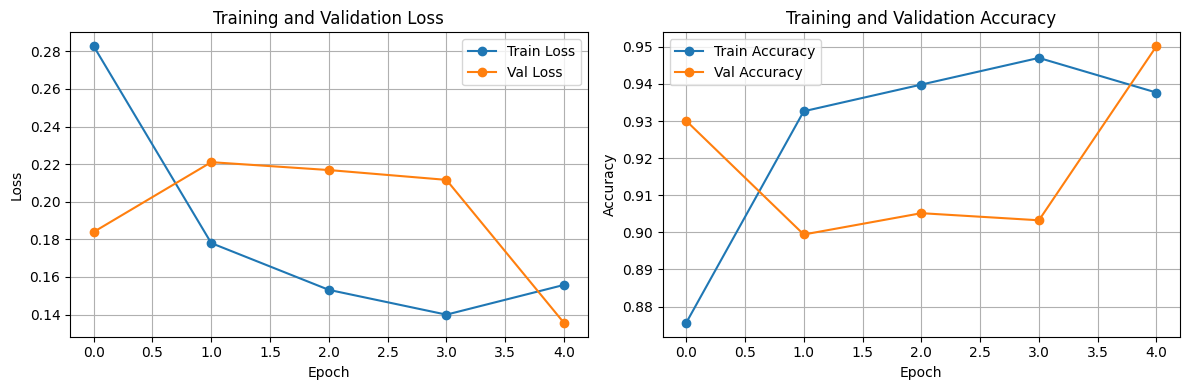

In [9]:
import time
import matplotlib.pyplot as plt

# 设置训练轮数（为了兼顾效果和时间，我们先练 5 轮看看实力）
num_epochs = 5

# 用于记录绘图数据的列表
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("🔥 炼丹炉已点火，开始训练！这大概需要几分钟，请耐心等待...")
since = time.time()

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    # ---------- 1. 训练阶段 ----------
    model.train()  # 告诉模型现在是训练模式
    running_loss = 0.0
    running_corrects = 0

    # 遍历训练集的数据批次
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # 清空过往梯度
        
        outputs = model(inputs) # 正向传播
        loss = criterion(outputs, labels) # 计算误差
        
        loss.backward() # 反向传播，计算当前梯度
        optimizer.step() # 根据梯度更新网络参数

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc.item())
    print(f'Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}')

    # ---------- 2. 验证阶段 ----------
    model.eval()  # 告诉模型现在是考试（评估）模式，不更新参数
    val_loss = 0.0
    val_corrects = 0

    with torch.no_grad(): # 考试时不需要计算梯度，省显存
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_epoch_loss = val_loss / len(val_dataset)
    val_epoch_acc = val_corrects.double() / len(val_dataset)
    val_losses.append(val_epoch_loss)
    val_accs.append(val_epoch_acc.item())
    print(f'Val Loss:   {val_epoch_loss:.4f} | Val Acc:   {val_epoch_acc:.4f}')

time_elapsed = time.time() - since
print(f'\n✅ 炼丹完成！总耗时: {time_elapsed // 60:.0f}分 {time_elapsed % 60:.0f}秒')

# ---------- 3. 绘制并展示训练曲线 (写报告必备) ----------
plt.figure(figsize=(12, 4))

# 绘制 Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 绘制 Accuracy 曲线
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy', marker='o')
plt.plot(val_accs, label='Val Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

🎓 正在测试集上进行最终考试，请稍等...

📊 测试集最终成绩单 (Classification Report)：
              precision    recall  f1-score   support

      NORMAL     0.9320    0.5855    0.7192       234
   PNEUMONIA     0.7966    0.9744    0.8766       390

    accuracy                         0.8285       624
   macro avg     0.8643    0.7799    0.7979       624
weighted avg     0.8474    0.8285    0.8176       624



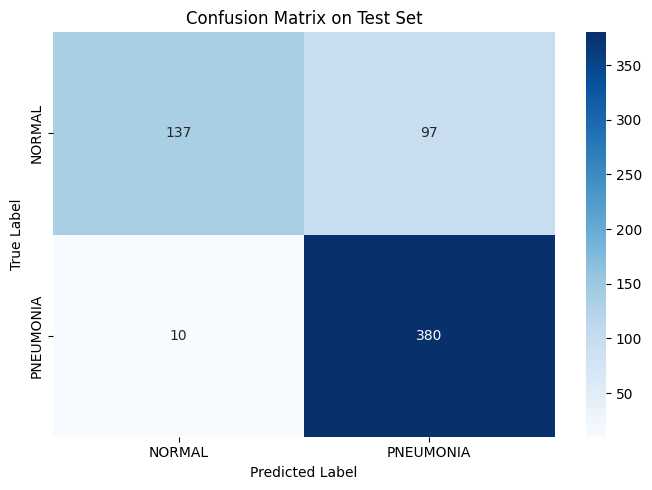

✅ 任务一全部完成！请将上面的文字表格和下方的图片截图保存用于报告。


In [11]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("🎓 正在测试集上进行最终考试，请稍等...")

# 告诉模型现在是评估模式，千万别在考试的时候还去修改参数
model.eval()

all_preds = []
all_labels = []

# 考试过程不需要计算梯度（省内存，跑得快）
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        # 把每一张图的真实标签和预测结果收集起来
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ----------------- 1. 输出 4 项核心指标 -----------------
print("\n📊 测试集最终成绩单 (Classification Report)：")
target_names = ['NORMAL', 'PNEUMONIA']  # 已经去掉了中文
print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

# ----------------- 2. 绘制混淆矩阵 (Confusion Matrix) -----------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix on Test Set')
plt.ylabel('True Label')   # 已经去掉了中文
plt.xlabel('Predicted Label') # 已经去掉了中文
plt.tight_layout()
plt.show()
print("✅ 任务一全部完成！请将上面的文字表格和下方的图片截图保存用于报告。")